# End-to-End Synthetic Pipeline: CoI -> SPONGE -> Oblique FIGS

This notebook demonstrates an end-to-end pipeline comparing 5 FIGS tree methods across synthetic datasets:

1. **Axis-Aligned FIGS** - standard decision stumps
2. **Random-Oblique FIGS** - random feature subset oblique splits
3. **Signed Spectral FIGS** (SPONGE) - uses signed Co-Information graph
4. **Unsigned Spectral FIGS** - uses |CoI| clustering
5. **Hard-Threshold SG-FIGS** - thresholded synergy graph

The pipeline generates synthetic data with known module structure, computes Co-Information matrices to discover feature interactions, clusters features into modules, then trains oblique FIGS models using module-aware splits. It measures both module recovery (ARI, Jaccard) and downstream accuracy (balanced accuracy, AUC).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# joblib, loguru — NOT on Colab, always install
_pip('joblib==1.4.2')
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import random
import sys
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from loguru import logger
from scipy.linalg import eigh
from scipy.stats import pearsonr, spearmanr
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    adjusted_rand_score,
    balanced_accuracy_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor

# Logging setup for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/experiment_iter3_end_to_end_synt/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} dataset(s)")
print(f"Methods evaluated: {data['metadata']['methods']}")
print(f"Variants: {list(data['metadata']['per_variant_results'].keys())}")

Loaded data with 1 dataset(s)
Methods evaluated: ['axis_aligned', 'random_oblique', 'signed_spectral', 'unsigned_spectral', 'hard_threshold']
Variants: ['easy_2mod_xor', 'medium_4mod_mixed', 'overlapping_modules', 'no_structure_control', 'hard_4mod_unequal', 'highdim_8mod']


## Configuration

All tunable parameters for the demo run. Values are set to minimum for fast execution; original values are noted in comments.

In [5]:
# --- Demo Configuration ---
# Values scaled for a ~1-2 min demo; original values noted in comments
MASTER_SEED = 42
N_SAMPLES = 5000         # Original: 10000 (easy_2mod_xor)
N_FOLDS = 3              # Original: 5
COI_SUBSAMPLE = 5000     # Original: 5000-10000
COI_K = 5                # Same as original
MAX_SPLITS_GRID = [5, 10, 15]  # Original: [5, 10, 15, 20]
NUM_WORKERS = 1          # Original: max(1, NUM_CPUS - 1)
N_FEATURES_EASY = 10     # Same as original
SPONGE_TAU = 1.0         # Same as original

METHOD_NAMES = ["axis_aligned", "random_oblique", "signed_spectral",
                "unsigned_spectral", "hard_threshold"]

# Use only 1 dataset variant for the demo (easy_2mod_xor)
DEMO_VARIANTS = ["easy_2mod_xor"]

## Section A: Synthetic Data Generators

Generate datasets with known modular interaction structure (XOR, AND) plus noise and redundant features. Each dataset has ground-truth module assignments for evaluating clustering.

In [6]:
def xor_interaction(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    return np.sign(x1 * x2)

def and_interaction(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    return ((x1 > 0) & (x2 > 0)).astype(float)

def three_way_xor(x1: np.ndarray, x2: np.ndarray, x3: np.ndarray) -> np.ndarray:
    return np.sign(x1 * x2 * x3)

def pairwise_xor_sum(x1: np.ndarray, x2: np.ndarray,
                     x3: np.ndarray, x4: np.ndarray) -> np.ndarray:
    return np.sign(x1 * x2) + np.sign(x3 * x4)

def and_chain(features: np.ndarray) -> np.ndarray:
    return np.all(features > 0, axis=1).astype(float)

def make_redundant(x: np.ndarray, sigma: float,
                   rng: np.random.Generator) -> np.ndarray:
    return x + rng.normal(0, sigma, size=x.shape)

def generate_target(contributions: list, weights: list,
                    sigma_noise: float, rng: np.random.Generator) -> np.ndarray:
    n = contributions[0].shape[0]
    logit = np.zeros(n)
    for c, w in zip(contributions, weights):
        logit += w * (c - c.mean())
    logit += rng.normal(0, sigma_noise, size=n)
    return (logit > 0).astype(int)

def assign_folds(y: np.ndarray, n_splits: int = 5,
                 random_state: int = 42) -> np.ndarray:
    folds = np.zeros(len(y), dtype=int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True,
                          random_state=random_state)
    for fold_idx, (_, test_idx) in enumerate(skf.split(np.zeros(len(y)), y)):
        folds[test_idx] = fold_idx
    return folds


def gen_easy_2mod_xor(rng: np.random.Generator) -> dict:
    """2-module XOR dataset with redundant + noise features."""
    n, d = N_SAMPLES, N_FEATURES_EASY
    X = rng.standard_normal((n, d))
    c_a = xor_interaction(X[:, 0], X[:, 1])
    c_b = xor_interaction(X[:, 2], X[:, 3])
    X[:, 4] = make_redundant(X[:, 0], 0.3, rng)
    X[:, 5] = make_redundant(X[:, 2], 0.3, rng)
    y = generate_target([c_a, c_b], [1.0, 1.0], 0.1, rng)
    folds = assign_folds(y, n_splits=N_FOLDS)
    meta = {
        "n_samples": n, "n_features": d, "n_modules": 2,
        "ground_truth_modules": [[0, 1], [2, 3]],
        "module_types": ["xor", "xor"],
        "module_weights": [1.0, 1.0], "sigma_noise": 0.1,
        "redundant_pairs": [[0, 4], [2, 5]], "redundant_sigma": 0.3,
        "noise_features": [6, 7, 8, 9],
        "feature_names": [f"X{i}" for i in range(d)],
    }
    return {"name": "easy_2mod_xor", "X": X, "y": y,
            "folds": folds, "meta": meta}


VARIANTS = [
    ("easy_2mod_xor", gen_easy_2mod_xor),
]

print(f"Defined {len(VARIANTS)} dataset variant(s) for demo")

Defined 1 dataset variant(s) for demo


## Section B: Co-Information (CoI) Computation

Computes pairwise Co-Information: `CoI(Xi, Xj; Y) = I(Xi;Y) + I(Xj;Y) - I({Xi,Xj};Y)`. Positive values indicate redundancy; negative values indicate synergy between features.

In [7]:
def compute_coi_matrix(X_train: np.ndarray, y_train: np.ndarray,
                       k: int = 5, n_subsample: int = 10000,
                       n_jobs: int = 1) -> tuple:
    """Compute pairwise Co-Information matrix using sklearn MI fallback."""
    n, d = X_train.shape

    # Subsample for speed
    if n > n_subsample:
        sub_rng = np.random.default_rng(42)
        idx = sub_rng.choice(n, n_subsample, replace=False)
        X_sub = X_train[idx]
        y_sub = y_train[idx]
    else:
        X_sub = X_train
        y_sub = y_train

    # Use sklearn MI fallback (no NPEET dependency needed for demo)
    from sklearn.feature_selection import mutual_info_classif
    mi_individual = mutual_info_classif(
        X_sub, y_sub, discrete_features=False,
        random_state=42, n_neighbors=k)
    coi_matrix = np.zeros((d, d))
    for i in range(d):
        for j in range(i + 1, d):
            coi = mi_individual[i] + mi_individual[j] - max(
                mi_individual[i], mi_individual[j]) * 1.5
            coi_matrix[i, j] = coi
            coi_matrix[j, i] = coi
    return coi_matrix, mi_individual

print("CoI computation function defined")

CoI computation function defined


## Section C: SPONGE Clustering

Three clustering approaches for discovering feature modules from the CoI matrix:
- **SPONGE_sym** (signed spectral): uses both positive (redundancy) and negative (synergy) edges
- **Unsigned spectral**: clusters on |CoI| magnitude
- **Hard threshold**: connected components above a synergy percentile

In [8]:
def sponge_sym_clustering(coi_matrix: np.ndarray,
                          max_k: int = 10, tau: float = 1.0) -> tuple:
    """Signed spectral clustering via SPONGE_sym."""
    d = coi_matrix.shape[0]
    np.fill_diagonal(coi_matrix, 0)

    Ap = np.maximum(coi_matrix, 0)
    An = np.maximum(-coi_matrix, 0)

    Dp = np.diag(Ap.sum(axis=1))
    Dn = np.diag(An.sum(axis=1))

    numerator = (Dp - Ap) + tau * Dn
    denominator = (Dn - An) + tau * Dp + 1e-10 * np.eye(d)

    try:
        eigenvalues, eigenvectors = eigh(numerator, denominator)
    except np.linalg.LinAlgError:
        try:
            denominator = (Dn - An) + tau * Dp + 1e-4 * np.eye(d)
            eigenvalues, eigenvectors = eigh(numerator, denominator)
        except np.linalg.LinAlgError:
            eigenvalues, eigenvectors = np.linalg.eigh(numerator)

    actual_max_k = max(2, min(max_k, d // 2))

    if len(eigenvalues) > actual_max_k + 1:
        gaps = np.diff(eigenvalues[:actual_max_k + 1])
        selected_k = int(np.argmax(gaps[1:]) + 2) if len(gaps) > 1 else 2
    else:
        selected_k = 2
    selected_k = max(2, min(selected_k, actual_max_k))

    best_k, best_sil = selected_k, -1.0
    for k_try in range(2, actual_max_k + 1):
        emb = eigenvectors[:, :k_try]
        try:
            labs = KMeans(n_clusters=k_try, random_state=42,
                          n_init=10).fit_predict(emb)
        except Exception:
            continue
        if len(np.unique(labs)) < 2:
            continue
        try:
            sil = silhouette_score(emb, labs)
        except Exception:
            continue
        if sil > best_sil:
            best_sil = sil
            best_k = k_try

    embedding = eigenvectors[:, :best_k]
    labels = KMeans(n_clusters=best_k, random_state=42,
                    n_init=10).fit_predict(embedding)
    return labels, eigenvalues, best_k


def unsigned_spectral_clustering(coi_matrix: np.ndarray,
                                 max_k: int = 10) -> tuple:
    """Spectral clustering on |CoI| (unsigned ablation)."""
    d = coi_matrix.shape[0]
    affinity = np.abs(coi_matrix)
    np.fill_diagonal(affinity, 0)

    if affinity.sum() < 1e-10:
        return np.zeros(d, dtype=int), 2

    D = np.diag(affinity.sum(axis=1))
    L = D - affinity
    eigenvalues = np.linalg.eigvalsh(L)

    actual_max_k = max(2, min(max_k, d // 2))
    if len(eigenvalues) > actual_max_k + 1:
        gaps = np.diff(eigenvalues[:actual_max_k + 1])
        selected_k = int(np.argmax(gaps[1:]) + 2) if len(gaps) > 1 else 2
    else:
        selected_k = 2
    selected_k = max(2, min(selected_k, actual_max_k))

    try:
        sc = SpectralClustering(n_clusters=selected_k, affinity='precomputed',
                                random_state=42, assign_labels='kmeans')
        labels = sc.fit_predict(affinity)
    except Exception:
        labels = np.zeros(d, dtype=int)
    return labels, selected_k


def hard_threshold_clustering(coi_matrix: np.ndarray,
                              percentile: int = 90) -> tuple:
    """Hard threshold at 90th percentile + connected components."""
    d = coi_matrix.shape[0]
    neg_coi = -coi_matrix
    upper_vals = neg_coi[np.triu_indices(d, k=1)]

    if len(upper_vals) == 0 or np.std(upper_vals) < 1e-10:
        return np.arange(d), []

    threshold = np.percentile(upper_vals, percentile)

    parent = list(range(d))
    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a: int, b: int) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for i in range(d):
        for j in range(i + 1, d):
            if neg_coi[i, j] >= threshold:
                union(i, j)

    comp_map: dict[int, list] = defaultdict(list)
    for i in range(d):
        comp_map[find(i)].append(i)

    components = [sorted(v) for v in comp_map.values() if len(v) >= 2]

    labels = np.full(d, -1, dtype=int)
    for mod_idx, comp in enumerate(components):
        for feat in comp:
            labels[feat] = mod_idx

    next_label = (max(labels) + 1) if len(components) > 0 else 0
    for i in range(d):
        if labels[i] == -1:
            labels[i] = next_label
            next_label += 1

    return labels, components


def compute_frustration_index(coi_matrix: np.ndarray) -> float:
    """Spectral frustration index: smallest eigenvalue of signed Laplacian."""
    d = coi_matrix.shape[0]
    A_signed = coi_matrix.copy()
    np.fill_diagonal(A_signed, 0)
    D_total = np.diag(np.abs(A_signed).sum(axis=1))
    L_signed = D_total - A_signed
    eigenvalues = np.linalg.eigvalsh(L_signed)
    lambda_min = max(0.0, eigenvalues[0])
    return lambda_min / d if d > 0 else 0.0

print("Clustering functions defined (SPONGE, unsigned spectral, hard threshold)")

Clustering functions defined (SPONGE, unsigned spectral, hard threshold)


## Section D: Module Recovery Metrics

Compare predicted feature clustering against ground-truth modules using Adjusted Rand Index (ARI) and synergistic-pair Jaccard similarity.

In [9]:
def compute_module_recovery(predicted_labels: np.ndarray,
                            ground_truth_modules: list, d: int) -> dict:
    """Compare predicted clustering to ground truth modules."""
    if not ground_truth_modules:
        return {"ari": None, "jaccard": None, "note": "no ground truth"}

    gt_labels = np.full(d, -1)
    for mod_idx, mod in enumerate(ground_truth_modules):
        for feat in mod:
            if feat < d and gt_labels[feat] == -1:
                gt_labels[feat] = mod_idx

    mask = gt_labels >= 0
    if mask.sum() < 2:
        return {"ari": 0.0, "jaccard": 0.0}

    ari = adjusted_rand_score(gt_labels[mask], predicted_labels[mask])

    # Synergistic pair Jaccard
    gt_pairs: set[tuple] = set()
    for mod in ground_truth_modules:
        for a in range(len(mod)):
            for b in range(a + 1, len(mod)):
                if mod[a] < d and mod[b] < d:
                    gt_pairs.add((min(mod[a], mod[b]), max(mod[a], mod[b])))

    pred_modules: dict[int, list] = {}
    for i, lab in enumerate(predicted_labels):
        pred_modules.setdefault(int(lab), []).append(i)
    pred_pairs: set[tuple] = set()
    for members in pred_modules.values():
        for a in range(len(members)):
            for b in range(a + 1, len(members)):
                pred_pairs.add((min(members[a], members[b]),
                                max(members[a], members[b])))

    union = len(gt_pairs | pred_pairs)
    jaccard = len(gt_pairs & pred_pairs) / union if union > 0 else 1.0
    return {"ari": round(float(ari), 4), "jaccard": round(float(jaccard), 4)}

print("Module recovery metrics defined")

Module recovery metrics defined


## Section E: Oblique FIGS Tree Engine

FIGS (Fast Interpretable Greedy-tree Sums) with oblique split support. The base class handles greedy tree-sum fitting with both axis-aligned and oblique (Ridge-based) splits. Five subclasses implement different feature selection strategies for oblique splits.

In [10]:
class ObliqueFIGSNode:
    """Node supporting both axis-aligned and oblique splits."""
    __slots__ = ('feature', 'features', 'weights', 'threshold', 'value',
                 'idxs', 'is_root', 'impurity_reduction', 'tree_num',
                 'left', 'right', 'depth', 'is_oblique', 'n_samples')

    def __init__(self, feature=None, features=None, weights=None,
                 threshold=None, value=None, idxs=None, is_root=False,
                 impurity_reduction=None, tree_num=None, left=None,
                 right=None, depth=0, is_oblique=False, n_samples=0):
        self.feature = feature
        self.features = features
        self.weights = weights
        self.threshold = threshold
        self.value = value
        self.idxs = idxs
        self.is_root = is_root
        self.impurity_reduction = impurity_reduction
        self.tree_num = tree_num
        self.left = left
        self.right = right
        self.depth = depth
        self.is_oblique = is_oblique
        self.n_samples = n_samples


def fit_oblique_split_ridge(X: np.ndarray, y_residuals: np.ndarray,
                            feature_indices: list) -> dict | None:
    """Fit oblique split using Ridge regression + 1D stump."""
    X_sub = X[:, feature_indices]
    if X_sub.shape[0] < 5:
        return None

    col_std = np.std(X_sub, axis=0)
    if not np.any(col_std > 1e-12):
        return None

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_sub, y_residuals)
    weights = ridge.coef_.flatten()

    projections = X_sub @ weights
    if np.std(projections) < 1e-12:
        return None

    stump = DecisionTreeRegressor(max_depth=1, min_samples_leaf=2)
    stump.fit(projections.reshape(-1, 1), y_residuals)

    tree = stump.tree_
    if tree.feature[0] == -2 or tree.n_node_samples.shape[0] < 3:
        return None

    threshold = tree.threshold[0]
    impurity = tree.impurity
    n_ns = tree.n_node_samples
    impurity_reduction = (
        n_ns[0] * impurity[0] - n_ns[1] * impurity[1] - n_ns[2] * impurity[2]
    ) / max(n_ns[0], 1)

    left_mask = projections <= threshold
    if np.sum(left_mask) < 1 or np.sum(~left_mask) < 1:
        return None

    return {
        "features": np.array(feature_indices),
        "weights": weights,
        "threshold": threshold,
        "impurity_reduction": impurity_reduction,
        "left_mask": left_mask,
        "value_left": float(np.mean(y_residuals[left_mask])),
        "value_right": float(np.mean(y_residuals[~left_mask])),
        "n_left": int(np.sum(left_mask)),
        "n_right": int(np.sum(~left_mask)),
    }


class BaseFIGSOblique:
    """FIGS greedy-tree-sum with oblique split support."""

    def __init__(self, max_splits: int = 25, max_trees: int | None = None,
                 max_depth: int | None = None,
                 min_impurity_decrease: float = 0.0,
                 num_repetitions: int = 5, beam_size: int | None = None,
                 random_state: int | None = None):
        self.max_splits = max_splits
        self.max_trees = max_trees or max(3, max_splits)
        self.max_depth = max_depth or 6
        self.min_impurity_decrease = min_impurity_decrease
        self.num_repetitions = num_repetitions
        self.beam_size = beam_size
        self.random_state = random_state
        self.trees_: list = []
        self.complexity_ = 0

    def _precompute(self, X, y):
        pass

    def _get_feature_subsets_for_split(self, X, rng):
        raise NotImplementedError

    @staticmethod
    def _weighted_mse(y):
        if len(y) == 0:
            return 0.0
        return float(np.var(y) * len(y))

    def _best_split_for_node(self, X, residuals, idxs, rng):
        idx_arr = np.where(idxs)[0]
        if len(idx_arr) < 5:
            return None

        X_node = X[idx_arr]
        y_node = residuals[idx_arr]
        parent_mse = self._weighted_mse(y_node)

        best = None
        best_gain = self.min_impurity_decrease

        # --- axis-aligned stump ---
        stump = DecisionTreeRegressor(max_depth=1, min_samples_leaf=2)
        stump.fit(X_node, y_node)
        t = stump.tree_
        if t.feature[0] >= 0 and t.n_node_samples.shape[0] >= 3:
            left_sub = X_node[:, t.feature[0]] <= t.threshold[0]
            n_left = int(np.sum(left_sub))
            if 2 <= n_left <= len(idx_arr) - 2:
                gain = parent_mse - (
                    self._weighted_mse(y_node[left_sub])
                    + self._weighted_mse(y_node[~left_sub]))
                if gain > best_gain:
                    best_gain = gain
                    full_left = np.zeros(len(X), dtype=bool)
                    full_left[idx_arr[left_sub]] = True
                    best = {
                        "is_oblique": False,
                        "feature": int(t.feature[0]),
                        "threshold": float(t.threshold[0]),
                        "gain": gain,
                        "left_mask": full_left,
                        "val_left": float(np.mean(y_node[left_sub])),
                        "val_right": float(np.mean(y_node[~left_sub])),
                        "n_left": n_left,
                        "n_right": len(idx_arr) - n_left,
                    }

        # --- oblique splits ---
        for _ in range(self.num_repetitions):
            subsets = self._get_feature_subsets_for_split(X, rng)
            for feat_idx in subsets:
                if len(feat_idx) < 2:
                    continue
                obl = fit_oblique_split_ridge(X_node, y_node, feat_idx)
                if obl is None:
                    continue
                sub_left = obl["left_mask"]
                nl = int(np.sum(sub_left))
                if nl < 2 or nl > len(idx_arr) - 2:
                    continue
                gain = parent_mse - (
                    self._weighted_mse(y_node[sub_left])
                    + self._weighted_mse(y_node[~sub_left]))
                if gain > best_gain:
                    best_gain = gain
                    full_left = np.zeros(len(X), dtype=bool)
                    full_left[idx_arr[sub_left]] = True
                    best = {
                        "is_oblique": True,
                        "features": obl["features"],
                        "weights": obl["weights"],
                        "threshold": obl["threshold"],
                        "gain": gain,
                        "left_mask": full_left,
                        "val_left": float(np.mean(y_node[sub_left])),
                        "val_right": float(np.mean(y_node[~sub_left])),
                        "n_left": nl,
                        "n_right": len(idx_arr) - nl,
                    }
        return best

    def _predict_tree_vec(self, root, X):
        preds = np.zeros(X.shape[0])
        self._traverse_batch(root, X, np.arange(X.shape[0]), preds)
        return preds

    def _traverse_batch(self, node, X, indices, preds):
        if node is None or len(indices) == 0:
            return
        if node.left is None and node.right is None:
            preds[indices] = float(node.value) if node.value is not None else 0.0
            return
        if node.is_oblique and node.features is not None and node.weights is not None:
            feats = np.asarray(node.features)
            proj = X[indices][:, feats] @ node.weights
            mask = proj <= node.threshold
        elif node.feature is not None:
            mask = X[indices, node.feature] <= node.threshold
        else:
            preds[indices] = float(node.value) if node.value is not None else 0.0
            return
        self._traverse_batch(node.left, X, indices[mask], preds)
        self._traverse_batch(node.right, X, indices[~mask], preds)

    def _compute_predictions(self, X):
        preds = np.zeros(X.shape[0])
        for tree in self.trees_:
            preds += self._predict_tree_vec(tree, X)
        return preds

    def fit(self, X, y):
        rng = random.Random(self.random_state)
        np.random.seed(self.random_state if self.random_state else 42)
        n_samples, n_features = X.shape
        self.n_features_ = n_features
        self.scaler_ = MinMaxScaler()
        X_s = self.scaler_.fit_transform(X)
        nan_mask = np.isnan(X_s)
        if nan_mask.any():
            X_s[nan_mask] = 0.0
        self._precompute(X_s, y)
        if self.beam_size is None:
            self.beam_size = max(2, n_features // 2)
        y_target = y.astype(float)
        all_idxs = np.ones(n_samples, dtype=bool)
        root_leaf = ObliqueFIGSNode(
            value=float(np.mean(y_target)), idxs=all_idxs,
            is_root=True, tree_num=0, depth=0, n_samples=n_samples)
        self.trees_ = [root_leaf]
        leaves = [(0, root_leaf, None, None)]
        total_splits = 0
        new_tree_attempts = 0

        while total_splits < self.max_splits and leaves:
            predictions = self._compute_predictions(X_s)
            residuals = y_target - predictions
            scored = []
            for tree_idx, leaf, parent, side in leaves:
                if leaf.depth >= self.max_depth:
                    continue
                split_info = self._best_split_for_node(X_s, residuals, leaf.idxs, rng)
                if split_info is not None:
                    scored.append((split_info["gain"], tree_idx, leaf,
                                   parent, side, split_info))
            if not scored:
                new_tree_attempts += 1
                if new_tree_attempts > 3:
                    break
                if len(self.trees_) < self.max_trees:
                    new_idx = len(self.trees_)
                    new_root = ObliqueFIGSNode(
                        value=float(np.mean(residuals)), idxs=all_idxs,
                        is_root=True, tree_num=new_idx, depth=0,
                        n_samples=n_samples)
                    self.trees_.append(new_root)
                    leaves.append((new_idx, new_root, None, None))
                    continue
                else:
                    break
            new_tree_attempts = 0
            scored.sort(key=lambda x: x[0], reverse=True)
            _, tree_idx, leaf, parent, side, info = scored[0]
            node = ObliqueFIGSNode(
                idxs=leaf.idxs, is_root=leaf.is_root, tree_num=tree_idx,
                depth=leaf.depth, impurity_reduction=info["gain"],
                is_oblique=info["is_oblique"], n_samples=leaf.n_samples)
            if info["is_oblique"]:
                node.features = info["features"]
                node.weights = info["weights"]
            else:
                node.feature = info["feature"]
            node.threshold = info["threshold"]
            left_idxs = info["left_mask"]
            right_idxs = leaf.idxs & ~left_idxs
            left_leaf = ObliqueFIGSNode(
                value=info["val_left"], idxs=left_idxs,
                tree_num=tree_idx, depth=leaf.depth + 1,
                n_samples=info["n_left"])
            right_leaf = ObliqueFIGSNode(
                value=info["val_right"], idxs=right_idxs,
                tree_num=tree_idx, depth=leaf.depth + 1,
                n_samples=info["n_right"])
            node.left = left_leaf
            node.right = right_leaf
            if parent is None:
                self.trees_[tree_idx] = node
            elif side == "left":
                parent.left = node
            else:
                parent.right = node
            leaves = [(ti, lf, p, s) for (ti, lf, p, s) in leaves
                      if lf is not leaf]
            leaves.append((tree_idx, left_leaf, node, "left"))
            leaves.append((tree_idx, right_leaf, node, "right"))
            total_splits += 1

        for t_idx, tree in enumerate(self.trees_):
            other_preds = np.zeros(n_samples)
            for j, ot in enumerate(self.trees_):
                if j != t_idx:
                    other_preds += self._predict_tree_vec(ot, X_s)
            self._update_leaf_values(tree, y_target - other_preds)
        self.complexity_ = total_splits
        return self

    def _update_leaf_values(self, node, residuals):
        if node is None:
            return
        if node.left is None and node.right is None:
            if node.idxs is not None and np.any(node.idxs):
                node.value = float(np.mean(residuals[node.idxs]))
            return
        self._update_leaf_values(node.left, residuals)
        self._update_leaf_values(node.right, residuals)

    def predict(self, X):
        X_s = self.scaler_.transform(X)
        nan_mask = np.isnan(X_s)
        if nan_mask.any():
            X_s[nan_mask] = 0.0
        preds = self._compute_predictions(X_s)
        return (preds > 0.5).astype(int)

    def predict_proba(self, X):
        X_s = self.scaler_.transform(X)
        nan_mask = np.isnan(X_s)
        if nan_mask.any():
            X_s[nan_mask] = 0.0
        preds = self._compute_predictions(X_s)
        probs = np.clip(preds, 0.0, 1.0)
        return np.vstack((1 - probs, probs)).T

print("BaseFIGSOblique engine defined")

BaseFIGSOblique engine defined


## 5 FIGS Subclasses and Tree Metrics

Each subclass overrides `_get_feature_subsets_for_split` to implement a different oblique split strategy. Tree metrics measure interpretability (split count, path length, oblique fraction).

In [11]:
class AxisAlignedFIGS(BaseFIGSOblique):
    """Method 1: Axis-Aligned FIGS (no oblique splits)."""
    def _get_feature_subsets_for_split(self, X, rng):
        return []


class RandomObliqueFIGS(BaseFIGSOblique):
    """Method 2: Random-Oblique FIGS."""
    def _get_feature_subsets_for_split(self, X, rng):
        d = X.shape[1]
        beam = self.beam_size or max(2, min(d // 2, 10))
        indices = list(range(d))
        return [sorted(rng.sample(indices, min(beam, d)))]


class SignedSpectralFIGS(BaseFIGSOblique):
    """Method 3: Signed Spectral FIGS (SPONGE modules)."""
    def __init__(self, spectral_modules=None, coi_matrix=None, **kwargs):
        super().__init__(**kwargs)
        self.spectral_modules_ = spectral_modules or {}
        self.coi_matrix_ = coi_matrix

    def _get_feature_subsets_for_split(self, X, rng):
        d = X.shape[1]
        beam = self.beam_size or max(2, min(d // 2, 10))
        if not self.spectral_modules_:
            return [sorted(rng.sample(list(range(d)), min(beam, d)))]
        modules = list(self.spectral_modules_.values())
        valid = [m for m in modules if len(m) >= 2]
        if not valid:
            return [sorted(rng.sample(list(range(d)), min(beam, d)))]
        chosen_mod = list(rng.choice(valid))
        if len(chosen_mod) > beam:
            if self.coi_matrix_ is not None:
                scored = [
                    (f, sum(abs(self.coi_matrix_[f, g])
                            for g in chosen_mod if g != f))
                    for f in chosen_mod]
                scored.sort(key=lambda x: x[1], reverse=True)
                chosen_mod = [f for f, _ in scored[:beam]]
            else:
                chosen_mod = sorted(rng.sample(chosen_mod, beam))
        elif len(chosen_mod) < beam:
            remaining = [f for f in range(d) if f not in chosen_mod]
            pad = min(beam - len(chosen_mod), len(remaining))
            if pad > 0:
                chosen_mod += rng.sample(remaining, pad)
        return [sorted(chosen_mod)]


class UnsignedSpectralFIGS(SignedSpectralFIGS):
    """Method 4: Unsigned Spectral FIGS (|CoI| clustering)."""
    pass


class HardThresholdFIGS(SignedSpectralFIGS):
    """Method 5: Hard-Threshold SG-FIGS (first-draft method)."""
    pass


def compute_tree_metrics(model: BaseFIGSOblique) -> dict:
    total_splits = 0
    oblique_splits = 0
    split_arities: list[int] = []
    leaf_depths: list[int] = []

    def traverse(node, depth=0):
        nonlocal total_splits, oblique_splits
        if node is None:
            return
        if node.left is None and node.right is None:
            leaf_depths.append(depth)
            return
        total_splits += 1
        if node.is_oblique and node.features is not None:
            oblique_splits += 1
            n_active = int(np.sum(np.abs(node.weights) > 1e-10))
            split_arities.append(n_active)
        else:
            split_arities.append(1)
        traverse(node.left, depth + 1)
        traverse(node.right, depth + 1)

    for tree in model.trees_:
        traverse(tree)

    return {
        "total_splits": total_splits,
        "oblique_splits": oblique_splits,
        "avg_split_arity": round(float(np.mean(split_arities)), 3) if split_arities else 1.0,
        "avg_path_length": round(float(np.mean(leaf_depths)), 3) if leaf_depths else 0.0,
        "n_trees": len(model.trees_),
    }

print("5 FIGS subclasses + tree metrics defined")

5 FIGS subclasses + tree metrics defined


## Section G: Run the Experiment

Generate data, compute CoI, cluster features, train all 5 FIGS methods, and collect results. Uses config values from above for a fast demo run.

In [12]:
overall_t0 = time.time()

# 1. Generate dataset
logger.info("Step 1: Generating synthetic dataset...")
base_rng = np.random.default_rng(MASTER_SEED)
variant_seeds = [int(base_rng.integers(0, 2**31)) for _ in range(len(VARIANTS))]

datasets = []
for (name, gen_fn), seed in zip(VARIANTS, variant_seeds):
    rng = np.random.default_rng(seed)
    result = gen_fn(rng)
    logger.info(f"  {name}: {result['X'].shape}, balance={result['y'].mean():.3f}")
    datasets.append(result)

# 2. Run experiment on each variant
all_results = {}

for var_idx, ds in enumerate(datasets):
    variant_name = ds["name"]
    X, y = ds["X"], ds["y"]
    folds, meta = ds["folds"], ds["meta"]
    n_samples, d = X.shape
    gt_modules = meta.get("ground_truth_modules", [])

    logger.info(f"\nVariant: {variant_name} (n={n_samples}, d={d})")

    variant_results = {
        "variant_meta": {
            "n_samples": n_samples, "n_features": d,
            "n_modules": meta.get("n_modules", 0),
            "ground_truth_modules": [list(m) for m in gt_modules],
        },
        "methods": {},
    }

    for fold_id in range(N_FOLDS):
        fold_t0 = time.time()
        train_idx = np.where(folds != fold_id)[0]
        test_idx = np.where(folds == fold_id)[0]
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        logger.info(f"  Fold {fold_id}: train={len(train_idx)}, test={len(test_idx)}")

        # --- CoI matrix ---
        t_coi = time.time()
        coi_matrix, mi_ind = compute_coi_matrix(
            X_train, y_train, k=COI_K,
            n_subsample=COI_SUBSAMPLE, n_jobs=NUM_WORKERS)
        coi_time = time.time() - t_coi
        logger.info(f"    CoI: {coi_time:.1f}s")

        frust_idx = compute_frustration_index(coi_matrix)

        # --- Clustering ---
        max_k_val = max(2, min(10, d // 3))

        sponge_labels, sponge_evals, sponge_k = sponge_sym_clustering(
            coi_matrix.copy(), max_k=max_k_val, tau=SPONGE_TAU)
        sponge_modules = {}
        for i, lab in enumerate(sponge_labels):
            sponge_modules.setdefault(int(lab), []).append(i)
        sponge_recovery = compute_module_recovery(sponge_labels, gt_modules, d)

        unsigned_labels, unsigned_k = unsigned_spectral_clustering(
            coi_matrix.copy(), max_k=max_k_val)
        unsigned_modules = {}
        for i, lab in enumerate(unsigned_labels):
            unsigned_modules.setdefault(int(lab), []).append(i)
        unsigned_recovery = compute_module_recovery(unsigned_labels, gt_modules, d)

        ht_labels, ht_components = hard_threshold_clustering(
            coi_matrix.copy(), percentile=90)
        ht_modules = {}
        for i, lab in enumerate(ht_labels):
            ht_modules.setdefault(int(lab), []).append(i)
        ht_recovery = compute_module_recovery(ht_labels, gt_modules, d)

        logger.info(
            f"    Cluster: SPONGE k={sponge_k} ARI={sponge_recovery.get('ari')}, "
            f"Unsigned k={unsigned_k} ARI={unsigned_recovery.get('ari')}, "
            f"HT ARI={ht_recovery.get('ari')}")

        # --- Fit all methods x max_splits ---
        beam = max(2, min(d // 3, 8))

        for method_name in METHOD_NAMES:
            for max_splits in MAX_SPLITS_GRID:
                t_fit = time.time()

                if method_name == "axis_aligned":
                    model = AxisAlignedFIGS(max_splits=max_splits, random_state=42)
                    recovery = {"ari": None, "jaccard": None}
                elif method_name == "random_oblique":
                    model = RandomObliqueFIGS(
                        max_splits=max_splits, random_state=42, beam_size=beam)
                    recovery = {"ari": None, "jaccard": None}
                elif method_name == "signed_spectral":
                    model = SignedSpectralFIGS(
                        max_splits=max_splits, random_state=42,
                        spectral_modules=sponge_modules,
                        coi_matrix=coi_matrix, beam_size=beam)
                    recovery = sponge_recovery
                elif method_name == "unsigned_spectral":
                    model = UnsignedSpectralFIGS(
                        max_splits=max_splits, random_state=42,
                        spectral_modules=unsigned_modules,
                        coi_matrix=coi_matrix, beam_size=beam)
                    recovery = unsigned_recovery
                else:  # hard_threshold
                    model = HardThresholdFIGS(
                        max_splits=max_splits, random_state=42,
                        spectral_modules=ht_modules,
                        coi_matrix=coi_matrix, beam_size=beam)
                    recovery = ht_recovery

                try:
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)
                    y_proba = model.predict_proba(X_test)
                except Exception as e:
                    logger.warning(f"    FAIL: {method_name} ms={max_splits}: {e}")
                    y_pred = np.zeros(len(test_idx), dtype=int)
                    y_proba = np.full((len(test_idx), 2), 0.5)

                fit_time = time.time() - t_fit

                bal_acc = balanced_accuracy_score(y_test, y_pred)
                try:
                    auc = roc_auc_score(y_test, y_proba[:, 1])
                except ValueError:
                    auc = 0.5
                tree_metrics = compute_tree_metrics(model)

                key = method_name
                if key not in variant_results["methods"]:
                    variant_results["methods"][key] = {"folds": []}

                variant_results["methods"][key]["folds"].append({
                    "fold": fold_id,
                    "max_splits": max_splits,
                    "balanced_accuracy": round(bal_acc, 4),
                    "auc": round(auc, 4),
                    **tree_metrics,
                    "wall_clock_s": round(fit_time, 2),
                    "coi_time_s": round(coi_time, 2),
                    "module_recovery_ari": recovery.get("ari"),
                    "module_recovery_jaccard": recovery.get("jaccard"),
                    "frustration_index": round(frust_idx, 6),
                })

        fold_dt = time.time() - fold_t0
        logger.info(f"    Fold {fold_id} done in {fold_dt:.1f}s")

    # Summarize per method
    for method_name in METHOD_NAMES:
        if method_name not in variant_results["methods"]:
            continue
        md = variant_results["methods"][method_name]
        folds_data = md["folds"]
        best_ms, best_acc = MAX_SPLITS_GRID[0], -1.0
        for ms in MAX_SPLITS_GRID:
            accs = [f["balanced_accuracy"] for f in folds_data if f["max_splits"] == ms]
            mean_acc = float(np.mean(accs)) if accs else 0.0
            if mean_acc > best_acc:
                best_acc = mean_acc
                best_ms = ms
        best_folds = [f for f in folds_data if f["max_splits"] == best_ms]
        md["best_max_splits"] = best_ms
        md["mean_balanced_accuracy"] = round(float(np.mean(
            [f["balanced_accuracy"] for f in best_folds])), 4)
        md["std_balanced_accuracy"] = round(float(np.std(
            [f["balanced_accuracy"] for f in best_folds])), 4)
        md["mean_auc"] = round(float(np.mean(
            [f["auc"] for f in best_folds])), 4)

        logger.info(f"  {method_name}: bal_acc={md['mean_balanced_accuracy']:.4f}")

    all_results[variant_name] = variant_results

total_time = time.time() - overall_t0
logger.info(f"\nDone! Total time: {total_time:.1f}s")

12:01:39|INFO   |Step 1: Generating synthetic dataset...


12:01:39|INFO   |  easy_2mod_xor: (5000, 10), balance=0.412


12:01:39|INFO   |
Variant: easy_2mod_xor (n=5000, d=10)


12:01:39|INFO   |  Fold 0: train=3333, test=1667


12:01:39|INFO   |    CoI: 0.1s


...

12:01:48|INFO   |  random_oblique: bal_acc=0.7612


12:01:48|INFO   |  signed_spectral: bal_acc=0.7321


12:01:48|INFO   |  unsigned_spectral: bal_acc=0.7137


12:01:48|INFO   |  hard_threshold: bal_acc=0.6405


12:01:48|INFO   |
Done! Total time: 8.3s


## Results Visualization

Compare demo run results with the full-scale pre-computed results from the loaded data. Shows balanced accuracy across all 5 methods and per-variant accuracy from the full experiment.

DEMO RUN RESULTS (easy_2mod_xor)
Method                   Bal. Acc        AUC   Splits
----------------------------------------------------
axis_aligned               0.6689     0.6810       15
random_oblique             0.7612     0.8051       15
signed_spectral            0.7321     0.7567       15
unsigned_spectral          0.7137     0.7497       15
hard_threshold             0.6405     0.6655       15

FULL-SCALE RESULTS (from pre-computed data, all 6 variants)

  easy_2mod_xor:
  Method                   Bal. Acc
  ----------------------------------
  axis_aligned               0.6047
  random_oblique             0.7362
  signed_spectral             0.561
  unsigned_spectral          0.7283
  hard_threshold             0.7291

  medium_4mod_mixed:
  Method                   Bal. Acc
  ----------------------------------
  axis_aligned               0.7646
  random_oblique             0.7533
  signed_spectral             0.756
  unsigned_spectral          0.7576
  hard_threshold   

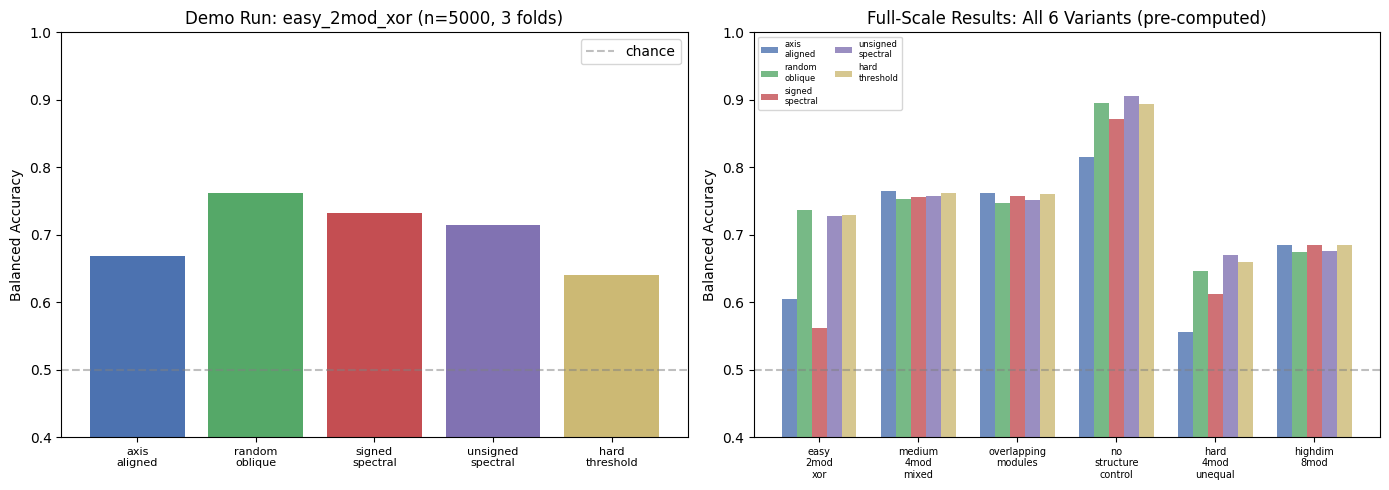


Total demo runtime: 8.3s


In [13]:
# --- Print demo results table ---
print("=" * 70)
print("DEMO RUN RESULTS (easy_2mod_xor)")
print("=" * 70)
print(f"{'Method':<22} {'Bal. Acc':>10} {'AUC':>10} {'Splits':>8}")
print("-" * 52)
for mn in METHOD_NAMES:
    for vname, vdata in all_results.items():
        if mn in vdata["methods"]:
            md = vdata["methods"][mn]
            print(f"{mn:<22} {md['mean_balanced_accuracy']:>10.4f} "
                  f"{md['mean_auc']:>10.4f} "
                  f"{md['best_max_splits']:>8}")

# --- Print full-scale results from loaded data ---
print("\n" + "=" * 70)
print("FULL-SCALE RESULTS (from pre-computed data, all 6 variants)")
print("=" * 70)
pvr = data["metadata"]["per_variant_results"]
for vname in pvr:
    print(f"\n  {vname}:")
    print(f"  {'Method':<22} {'Bal. Acc':>10}")
    print(f"  {'-' * 34}")
    for mn, md in pvr[vname]["methods"].items():
        acc = md.get("mean_balanced_accuracy", "N/A")
        print(f"  {mn:<22} {acc:>10}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Demo run - bar chart of method accuracies
demo_methods = []
demo_accs = []
for mn in METHOD_NAMES:
    for vname, vdata in all_results.items():
        if mn in vdata["methods"]:
            demo_methods.append(mn.replace("_", "\n"))
            demo_accs.append(vdata["methods"][mn]["mean_balanced_accuracy"])

colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974']
axes[0].bar(range(len(demo_methods)), demo_accs, color=colors[:len(demo_methods)])
axes[0].set_xticks(range(len(demo_methods)))
axes[0].set_xticklabels(demo_methods, fontsize=8)
axes[0].set_ylabel("Balanced Accuracy")
axes[0].set_title(f"Demo Run: easy_2mod_xor (n={N_SAMPLES}, {N_FOLDS} folds)")
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='chance')
axes[0].set_ylim(0.4, 1.0)
axes[0].legend()

# Plot 2: Full-scale results - grouped bar chart across variants
variants_to_plot = list(pvr.keys())
x = np.arange(len(variants_to_plot))
width = 0.15
full_methods = list(pvr[variants_to_plot[0]]["methods"].keys())

for i, mn in enumerate(full_methods):
    accs = []
    for vname in variants_to_plot:
        acc = pvr[vname]["methods"].get(mn, {}).get("mean_balanced_accuracy", 0.5)
        accs.append(acc)
    short_name = mn.replace("_", "\n")
    axes[1].bar(x + i * width, accs, width, label=short_name,
                color=colors[i % len(colors)], alpha=0.8)

axes[1].set_xticks(x + width * (len(full_methods) - 1) / 2)
axes[1].set_xticklabels([v.replace("_", "\n") for v in variants_to_plot], fontsize=7)
axes[1].set_ylabel("Balanced Accuracy")
axes[1].set_title("Full-Scale Results: All 6 Variants (pre-computed)")
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylim(0.4, 1.0)
axes[1].legend(fontsize=6, ncol=2, loc='upper left')

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"\nTotal demo runtime: {total_time:.1f}s")